# Cardiovascular Disease Prediction

This notebook serves as the **central hub** for the cardiovascular disease prediction project. It imports and orchestrates modularized Python scripts from `src/` to maintain clean architecture and code reusability

## 1. Setup & Imports

Import all necessary libraries and modules from `src/`

In [1]:
import sys
import pandas as pd
import numpy as np
import os
import warnings
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
sys.path.append('./')
from src.features.build_features import clean_data, split_and_scale, engineer_features
from src.models.train import (
    train_logistic_regression,
    train_naive_bayes,
    train_decision_tree,
    train_linear_svm,
    evaluate_model
)
from src.models.predict import load_model, predict_single_instance
from src.models.confidence_analysis import analyze_confidence, print_confidence_report
from src.models.learning_curves import plot_learning_curve
from src.models.threshold_analysis import (
    apply_threshold, calculate_confusion_metrics, 
    compare_thresholds, print_confusion_breakdown
)
from scipy.special import expit

## 2. Data Exploration

Load and explore the raw cardiovascular disease dataset

In [2]:
# Load raw data
df = pd.read_csv('data/raw/cardio_train.csv', sep=';')
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumn names and types:")
print(df.dtypes)
print(f"\nFirst few rows:")
print(df.head())

Shape: 70000 rows, 13 columns

Column names and types:
id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

First few rows:
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4   

## 3. Data Cleaning & Feature Engineering

Using `src/features/build_features.py` to clean data and prepare features

In [3]:
df_cleaned = clean_data(df)
print(f"\nOriginal dataset: {df.shape[0]} rows")
print(f"Cleaned dataset:  {df_cleaned.shape[0]} rows")
print(f"Rows removed:     {df.shape[0] - df_cleaned.shape[0]}")
print(f"\nRemaining columns: {df_cleaned.shape[1]}")
print(f"Data types:\n{df_cleaned.dtypes}")


Original dataset: 70000 rows
Cleaned dataset:  68810 rows
Rows removed:     1190

Remaining columns: 12
Data types:
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object


In [4]:
X_train, X_test, y_train, y_test, scaler = split_and_scale(df_cleaned)
print(f"\nTraining set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test set:     {X_test.shape[0]} samples, {X_test.shape[1]} features")


Training set: 55048 samples, 11 features
Test set:     13762 samples, 11 features


## 4. Model Training

Using `src/models/train.py` to train multiple classification models

In [5]:
models = {}
models['Logistic Regression'] = train_logistic_regression(X_train, y_train)
models['Naive Bayes'] = train_naive_bayes(X_train, y_train)
models['Decision Tree'] = train_decision_tree(X_train, y_train, max_depth=7)
models['Linear SVM'] = train_linear_svm(X_train, y_train)

## 5. Model Evaluation

Using `src/models/train.py`'s `evaluate_model()` function to assess performance

In [6]:
# eval models
results = {}
for model_name, model in models.items():
    metrics = evaluate_model(model, X_test, y_test)
    results[model_name] = metrics
    
    print(f"\n{model_name}:")
    print(f"  Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1-Score:  {metrics['f1_score']:.4f}")

results_df = pd.DataFrame(results).T
best_model_acc_score = results_df['accuracy'].max()
best_model_acc_name = results_df['accuracy'].idxmax()
best_acc = results_df['accuracy'].max()
best_model_recall_score = results_df['recall'].max()
best_model_recall_name = results_df['recall'].idxmax()
best_recall = results_df['recall'].max()
best_model_f1_score = results_df['f1_score']
best_model_f1_name = best_model_f1_score.idxmax()
best_f1 = best_model_f1_score.max()
print(f"\nBest Model (by Accuracy): {best_model_acc_name} ({best_acc:.4f})")
print(f"Best Model (by Recall):   {best_model_recall_name} ({best_recall:.4f})")
print(f"Best Model (by F1-Score): {best_model_f1_name} ({best_f1:.4f})")


Logistic Regression:
  Accuracy:  0.7303
  Precision: 0.7544
  Recall:    0.6748
  F1-Score:  0.7124

Naive Bayes:
  Accuracy:  0.7117
  Precision: 0.7612
  Recall:    0.6084
  F1-Score:  0.6763

Decision Tree:
  Accuracy:  0.7317
  Precision: 0.7387
  Recall:    0.7083
  F1-Score:  0.7232

Linear SVM:
  Accuracy:  0.7295
  Precision: 0.7577
  Recall:    0.6666
  F1-Score:  0.7092

Best Model (by Accuracy): Decision Tree (0.7317)
Best Model (by Recall):   Decision Tree (0.7083)
Best Model (by F1-Score): Decision Tree (0.7232)


## 6. Confusion Matrices

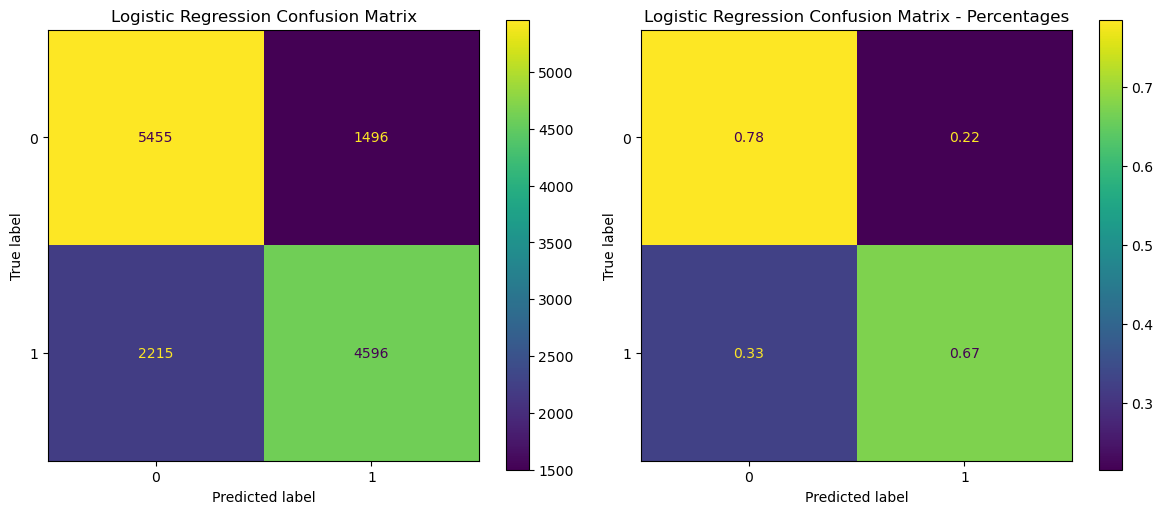

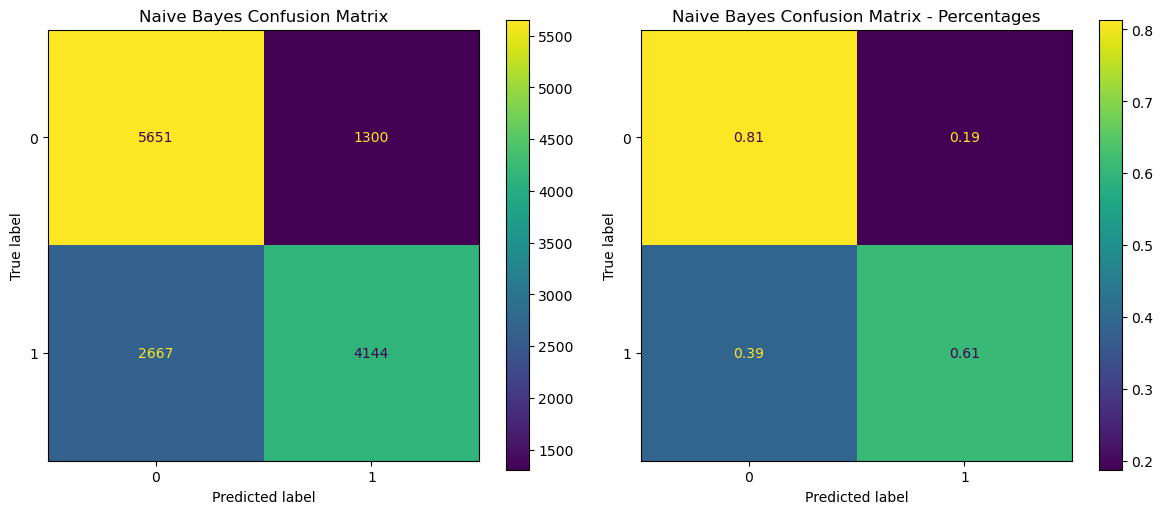

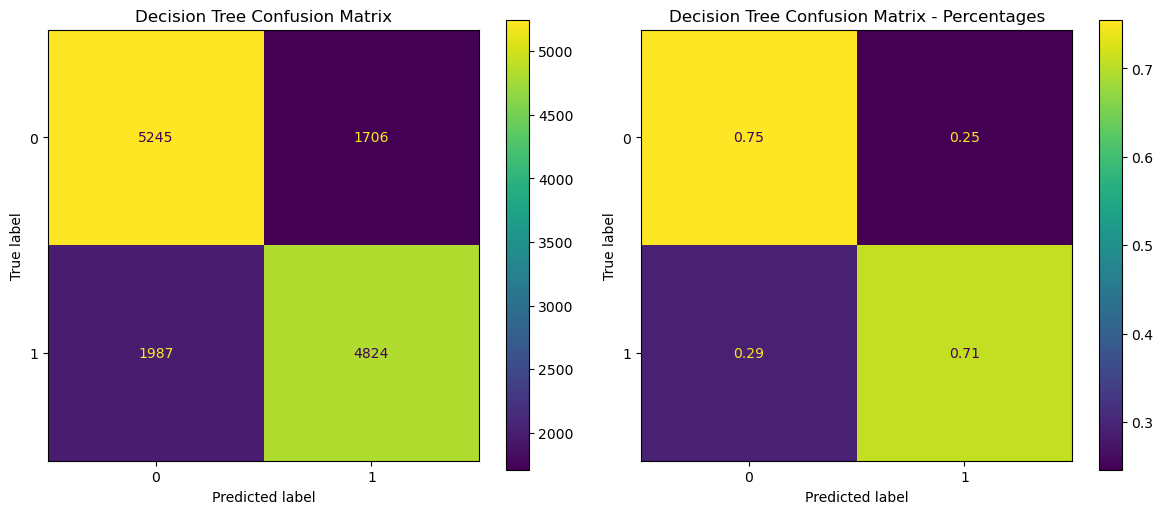

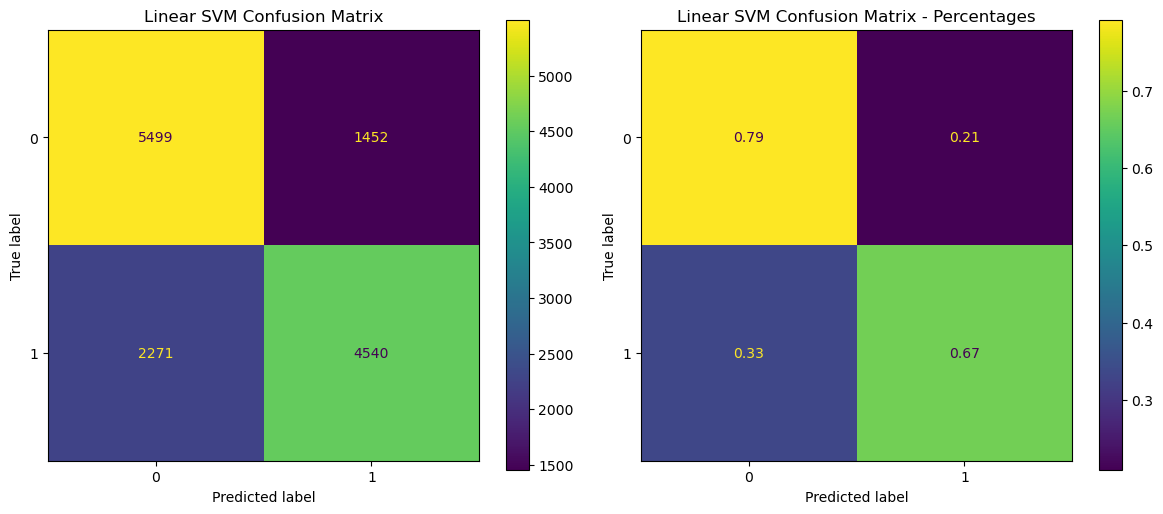

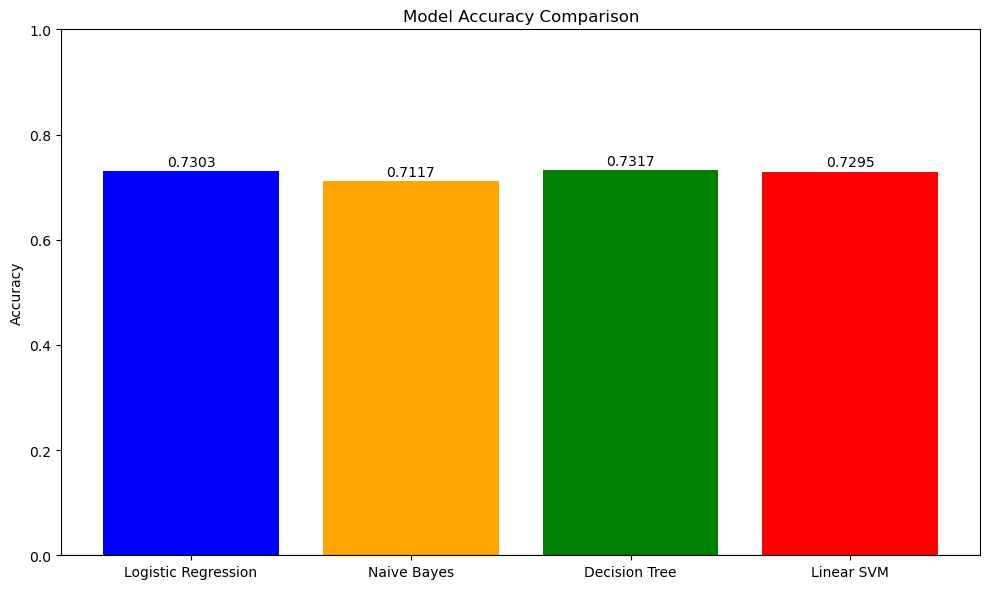

In [7]:
os.makedirs('output/plots/confusion_matrices', exist_ok=True)

for model_name, model in models.items():
    predictions = model.predict(X_test)
    cm = confusion_matrix(y_test, predictions)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(ax=axes[0])
    axes[0].set_title(f"{model_name} Confusion Matrix")
    cm_perc = confusion_matrix(y_test, predictions, normalize="true")
    disp_perc = ConfusionMatrixDisplay(confusion_matrix=cm_perc, display_labels=model.classes_)
    disp_perc.plot(ax=axes[1])
    axes[1].set_title(f"{model_name} Confusion Matrix - Percentages")
    plt.tight_layout()
    
    # Save the confusion matrix plot
    filename = f"output/plots/confusion_matrices/{model_name.replace(' ', '_').lower()}_confusion_matrix.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# model comparison plot
model_names = list(models.keys())
accuracies = [results[m]['accuracy'] for m in model_names]
plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracies, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.01, f"{acc:.4f}", ha='center')
plt.xticks(rotation=0, ha='center')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()

# Save the accuracy comparison plot
plt.savefig('output/plots/01_model_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Check Overfitting

Analyze train vs test accuracy to detect overfitting

In [8]:
models_eval = [
    ("Logistic Regression", models['Logistic Regression']),
    ("Naive Bayes", models['Naive Bayes']),
    ("Linear SVM", models['Linear SVM'])
]
print("Overfitting Analysis (Test Accuracy - Train Accuracy):\n")
for model_name, model in models_eval:
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    diff = test_acc - train_acc
    print(f"{model_name}: {diff:.4f}")
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy:  {test_acc:.4f}\n")

Overfitting Analysis (Test Accuracy - Train Accuracy):

Logistic Regression: 0.0034
  Train Accuracy: 0.7269
  Test Accuracy:  0.7303

Naive Bayes: 0.0027
  Train Accuracy: 0.7091
  Test Accuracy:  0.7117

Linear SVM: 0.0039
  Train Accuracy: 0.7256
  Test Accuracy:  0.7295



## 8. Models Confidence
Evaluate model confidence on hits and misses to understand reliability

In [9]:
# Extract predictions from trained models
baseline = models['Logistic Regression']
baseline_pred = baseline.predict(X_test)

nb = models['Naive Bayes']
nb_pred = nb.predict(X_test)

svm_linear = models['Linear SVM']
svm_linear_pred = svm_linear.predict(X_test)

# Baseline Model
baseline_probs = baseline.predict_proba(X_test)
baseline_stats = analyze_confidence(baseline_pred, baseline_probs, y_test, "Baseline")
print_confidence_report(baseline_stats)

# Naive Bayes
nb_probs = nb.predict_proba(X_test)
nb_stats = analyze_confidence(nb_pred, nb_probs, y_test, "Naive Bayes")
print_confidence_report(nb_stats)

# Linear SVM
svm_scores = svm_linear.decision_function(X_test)
svm_probs = expit(svm_scores)
svm_stats = analyze_confidence(svm_linear_pred, svm_probs, y_test, "Linear SVM")
print_confidence_report(svm_stats)

Baseline Confidence on Hits:
  Average: 0.7266, Max: 0.9992, Min: 0.5001
  Count: 10051
Baseline Confidence on Misses:
  Average: 0.6563, Max: 0.9988, Min: 0.5000
  Count: 3711

Naive Bayes Confidence on Hits:
  Average: 0.8664, Max: 1.0000, Min: 0.5000
  Count: 9795
Naive Bayes Confidence on Misses:
  Average: 0.7974, Max: 1.0000, Min: 0.5002
  Count: 3967

Linear SVM Confidence on Hits:
  Average: 0.6058, Max: 0.9402, Min: 0.5000
  Count: 10039
Linear SVM Confidence on Misses:
  Average: 0.5697, Max: 0.9320, Min: 0.5001
  Count: 3723



## 9. Threshold Analysis

Compare model predictions using 50% (default) vs 60% confidence thresholds

In [10]:
baseline_probs_pos = baseline.predict_proba(X_test)[:, 1]
baseline_comparison = compare_thresholds(baseline_probs_pos, y_test, [0.4, 0.5, 0.6], "Baseline")
baseline_metrics_40 = calculate_confusion_metrics(y_test, apply_threshold(baseline_probs_pos, 0.4))
baseline_metrics_50 = calculate_confusion_metrics(y_test, apply_threshold(baseline_probs_pos, 0.5))
baseline_metrics_60 = calculate_confusion_metrics(y_test, apply_threshold(baseline_probs_pos, 0.6))
print_confusion_breakdown(baseline_metrics_40, "Baseline", 0.4)
print_confusion_breakdown(baseline_metrics_50, "Baseline", 0.5)
print_confusion_breakdown(baseline_metrics_60, "Baseline", 0.6)


nb_probs_pos = nb.predict_proba(X_test)[:, 1]
nb_comparison = compare_thresholds(nb_probs_pos, y_test, [0.4, 0.5, 0.6], "Naive Bayes")
nb_metrics_40 = calculate_confusion_metrics(y_test, apply_threshold(nb_probs_pos, 0.4))
nb_metrics_50 = calculate_confusion_metrics(y_test, apply_threshold(nb_probs_pos, 0.5))
nb_metrics_60 = calculate_confusion_metrics(y_test, apply_threshold(nb_probs_pos, 0.6))
print_confusion_breakdown(nb_metrics_40, "Naive Bayes", 0.4)
print_confusion_breakdown(nb_metrics_50, "Naive Bayes", 0.5)
print_confusion_breakdown(nb_metrics_60, "Naive Bayes", 0.6)

svm_probs_pos = expit(svm_linear.decision_function(X_test))
svm_comparison = compare_thresholds(svm_probs_pos, y_test, [0.4, 0.5, 0.6], "Linear SVM")
svm_metrics_40 = calculate_confusion_metrics(y_test, apply_threshold(svm_probs_pos, 0.4))
svm_metrics_50 = calculate_confusion_metrics(y_test, apply_threshold(svm_probs_pos, 0.5))
svm_metrics_60 = calculate_confusion_metrics(y_test, apply_threshold(svm_probs_pos, 0.6))
print_confusion_breakdown(svm_metrics_40, "Linear SVM", 0.4)
print_confusion_breakdown(svm_metrics_50, "Linear SVM", 0.5)
print_confusion_breakdown(svm_metrics_60, "Linear SVM", 0.6)


Baseline - Threshold Comparison:
                accuracy  precision    recall  f1_score
Threshold: 40%  0.712832   0.676416  0.804728  0.735014
Threshold: 50%  0.730344   0.754432  0.674791  0.712392
Threshold: 60%  0.714867   0.804343  0.560123  0.660377



Baseline (Threshold: 40%) - Confusion Matrix Breakdown:
  True Positives (TP):   5481 (39.83%)
  False Positives (FP):  2622 (19.05%)
  True Negatives (TN):   4329 (31.46%)
  False Negatives (FN):  1330 ( 9.66%)
  Total: 13762

Baseline (Threshold: 50%) - Confusion Matrix Breakdown:
  True Positives (TP):   4596 (33.40%)
  False Positives (FP):  1496 (10.87%)
  True Negatives (TN):   5455 (39.64%)
  False Negatives (FN):  2215 (16.10%)
  Total: 13762

Baseline (Threshold: 60%) - Confusion Matrix Breakdown:
  True Positives (TP):   3815 (27.72%)
  False Positives (FP):   928 ( 6.74%)
  True Negatives (TN):   6023 (43.77%)
  False Negatives (FN):  2996 (21.77%)
  Total: 13762

Naive Bayes - Threshold Comparison:
                accuracy  precision    recall  f1_score
Threshold: 40%  0.718718   0.743458  0.659081  0.698731
Threshold: 50%  0.711742   0.761205  0.608428  0.676295
Threshold: 60%  0.700916   0.773271  0.559830  0.649463

Naive Bayes (Threshold: 40%) - Confusion Matrix Breakd

In [17]:
# Export threshold analysis metrics to CSV
os.makedirs('output/metrics', exist_ok=True)
threshold_metrics_data = []

for model_name, metrics_40, metrics_50, metrics_60 in [
    ("Logistic Regression", baseline_metrics_40, baseline_metrics_50, baseline_metrics_60),
    ("Naive Bayes", nb_metrics_40, nb_metrics_50, nb_metrics_60),
    ("Linear SVM", svm_metrics_40, svm_metrics_50, svm_metrics_60)
]:
    for threshold, metrics in [(0.4, metrics_40), (0.5, metrics_50), (0.6, metrics_60)]:
        threshold_metrics_data.append({
            'Model': model_name,
            'Threshold': threshold,
            'TP': metrics['TP'],
            'TN': metrics['TN'],
            'FP': metrics['FP'],
            'FN': metrics['FN'],
            'Accuracy': metrics['accuracy'],
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'F1-Score': metrics['f1_score']
        })

threshold_df = pd.DataFrame(threshold_metrics_data)
threshold_df.to_csv('output/metrics/threshold_analysis_comparison.csv', index=False)

## 10. Baseline vs Feature-Engineered Comparison

In [12]:
# Prepare feature-engineered dataset for comparison
X_train_eng, X_test_eng, y_train_eng, y_test_eng, scaler_eng = split_and_scale(
    df_cleaned, use_feature_engineering=True
)

print(f"Dataset Comparison:")
print(f"  Baseline features: {X_train.shape[1]}")
print(f"  Engineered features: {X_train_eng.shape[1]}")
print(f"  Engineered includes: BMI, age_years (drops age, height, weight)\n")

# Train feature-engineered models
engineered_models = {}
engineered_results = {}

print("Training Feature-Engineered Models:")
engineered_models['Logistic Regression'] = train_logistic_regression(X_train_eng, y_train_eng)
engineered_models['Naive Bayes'] = train_naive_bayes(X_train_eng, y_train_eng)
engineered_models['Decision Tree'] = train_decision_tree(X_train_eng, y_train_eng, max_depth=7)
engineered_models['Linear SVM'] = train_linear_svm(X_train_eng, y_train_eng)

print("\nFeature-Engineered Model Performance:")
for model_name, model in engineered_models.items():
    metrics = evaluate_model(model, X_test_eng, y_test_eng)
    engineered_results[model_name] = metrics
    print(f"\n{model_name}:")
    print(f"  Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1-Score:  {metrics['f1_score']:.4f}")

Dataset Comparison:
  Baseline features: 11
  Engineered features: 10
  Engineered includes: BMI, age_years (drops age, height, weight)

Training Feature-Engineered Models:

Feature-Engineered Model Performance:

Logistic Regression:
  Accuracy:  0.7296
  Precision: 0.7550
  Recall:    0.6717
  F1-Score:  0.7109

Naive Bayes:
  Accuracy:  0.7118
  Precision: 0.7635
  Recall:    0.6052
  F1-Score:  0.6752

Decision Tree:
  Accuracy:  0.7297
  Precision: 0.7307
  Recall:    0.7187
  F1-Score:  0.7246

Linear SVM:
  Accuracy:  0.7288
  Precision: 0.7588
  Recall:    0.6628
  F1-Score:  0.7075


In [13]:
os.makedirs('data/processed', exist_ok=True)

df_engineered = engineer_features(df_cleaned)
df_engineered.to_csv('data/processed/cardio_train_cleaned_bmi.csv', index=False)
print(f"Engineered dataset saved to: data/processed/cardio_train_cleaned_bmi.csv")
print(f"Shape: {df_engineered.shape}")
print(f"Features: {df_engineered.columns.tolist()}")

Engineered dataset saved to: data/processed/cardio_train_cleaned_bmi.csv
Shape: (68810, 11)
Features: ['gender', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'bmi', 'age_years']


## 11. Learning Curves Analysis

Analyze bias-variance trade-offs by examining how model performance changes with training set size. This helps diagnose underfitting and overfitting issues.

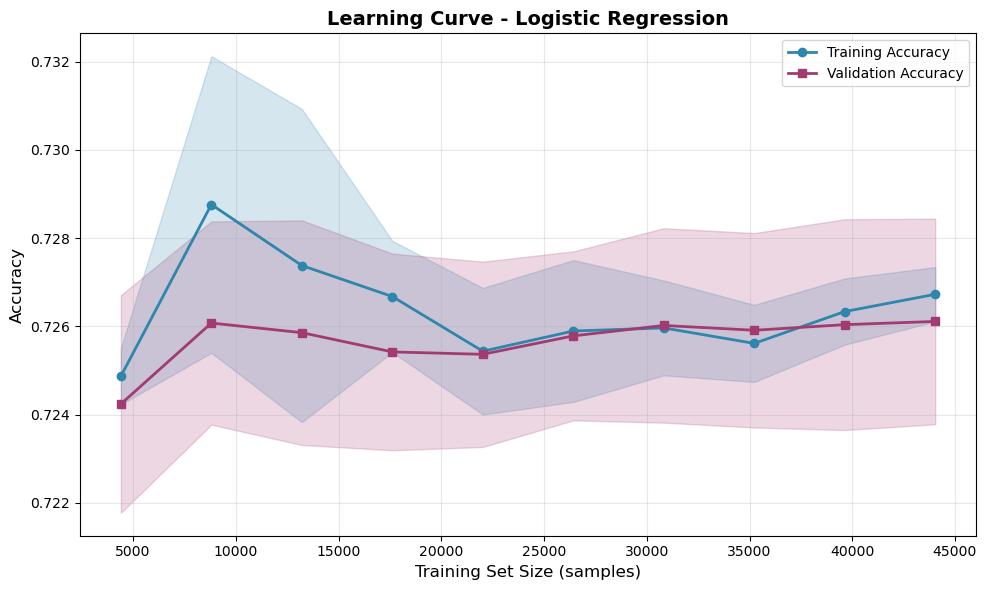

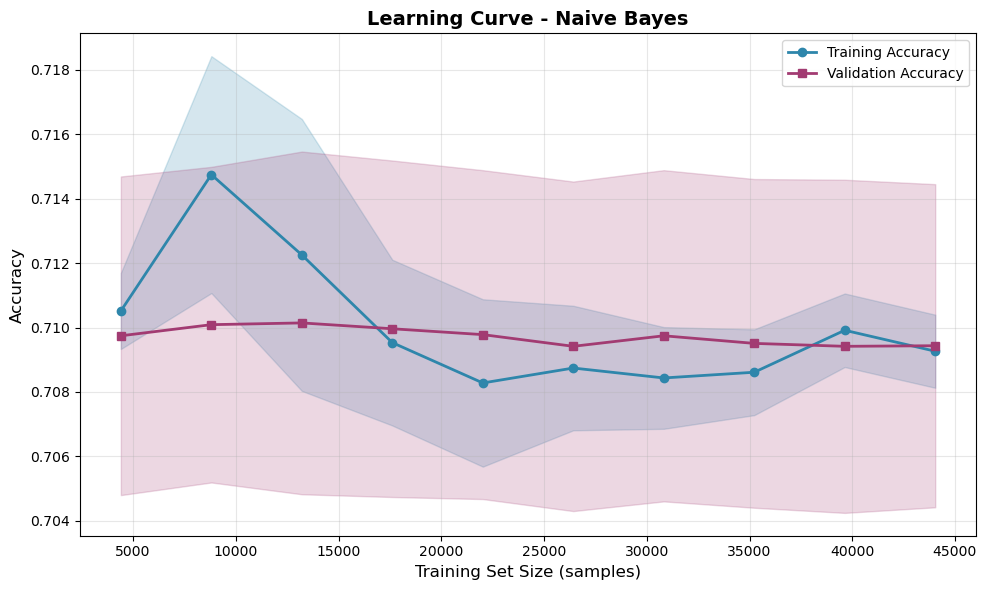

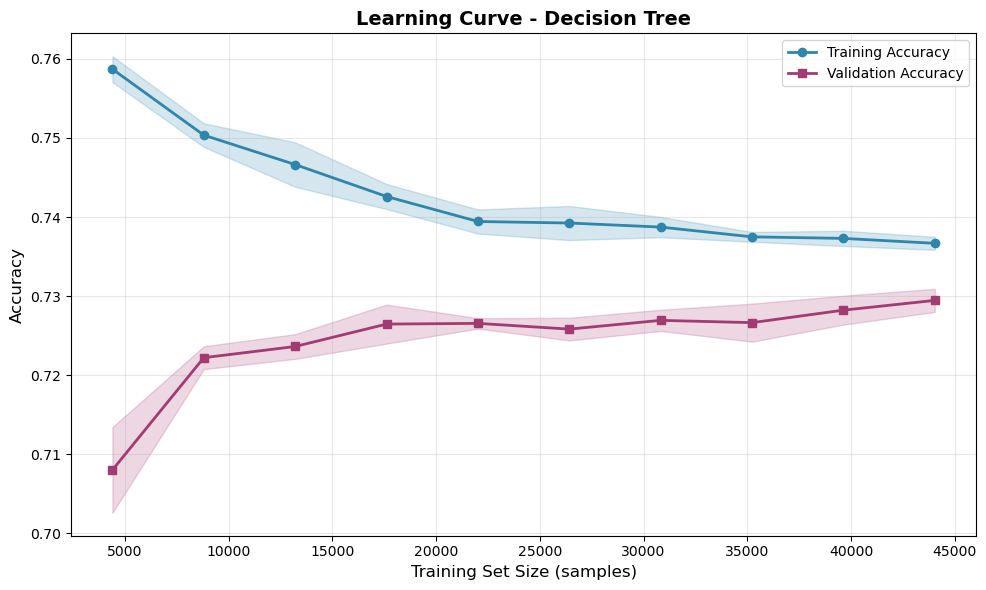

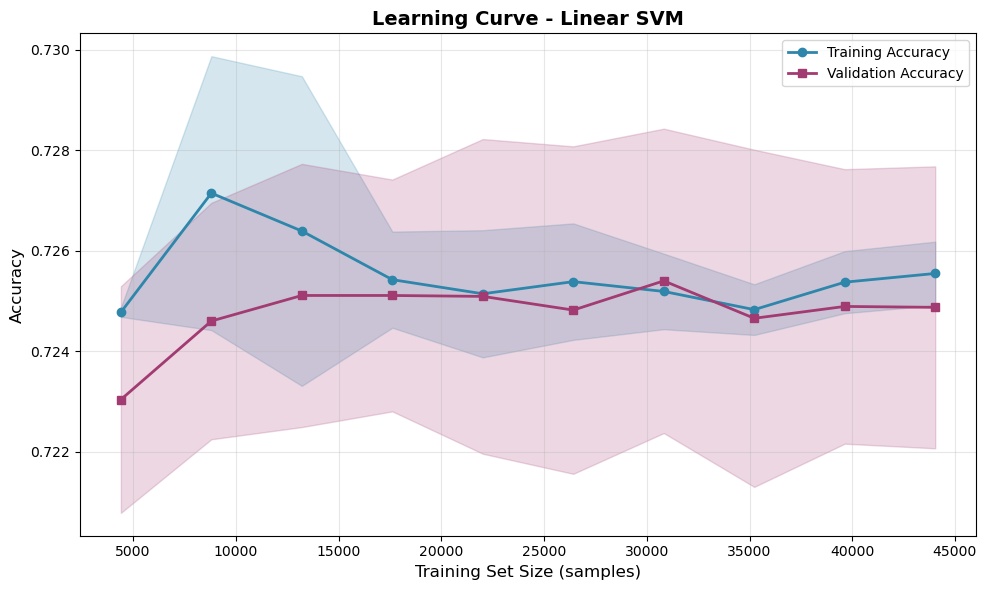

In [14]:
os.makedirs('output/plots/learning_curves', exist_ok=True)

learning_curve_results = {}

for model_name, model in models.items():
    # Generate learning curve
    lc_results = plot_learning_curve(
        model, X_train, y_train, 
        cv=5,
        title=f"Learning Curve - {model_name}",
        train_sizes=np.linspace(0.1, 1.0, 10)
    )
    learning_curve_results[model_name] = lc_results
    
    # Save the learning curve plot
    filename = f"output/plots/learning_curves/{model_name.replace(' ', '_').lower()}_learning_curve.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')

## 12. Visualization: Model Comparison

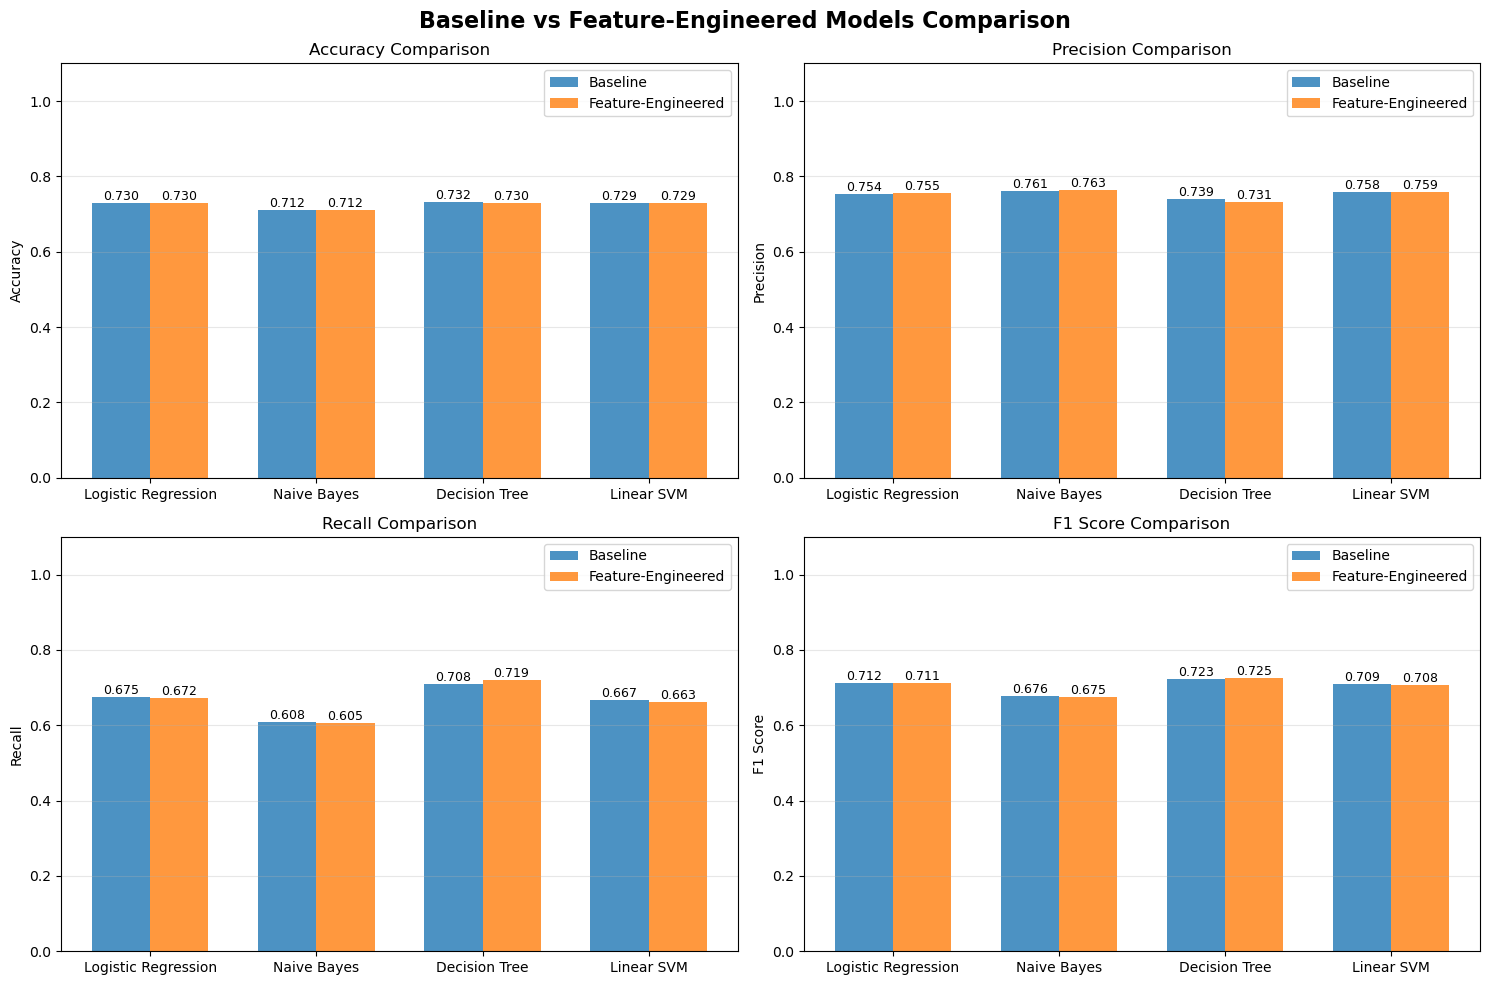

In [15]:
# Re-evaluate models to ensure we have clean results (in case variables were overwritten)
eval_results = {}
for model_name, model in models.items():
    metrics = evaluate_model(model, X_test, y_test)
    eval_results[model_name] = metrics

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Baseline vs Feature-Engineered Models Comparison', fontsize=16, fontweight='bold')

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_score']
model_names_list = list(eval_results.keys())

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    baseline_values = [eval_results[model_name][metric] for model_name in model_names_list]
    engineered_values = [engineered_results[model_name][metric] for model_name in model_names_list]
    
    x = np.arange(len(model_names_list))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, baseline_values, width, label='Baseline', alpha=0.8)
    bars2 = ax.bar(x + width/2, engineered_values, width, label='Feature-Engineered', alpha=0.8)
    
    # Add value labels on top of bars
    for bar in bars1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)
    
    for bar in bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)
    
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.set_title(f'{metric.replace("_", " ").title()} Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names_list, rotation=0, ha='center')
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
# Save the model comparison plot
plt.savefig('output/plots/02_baseline_vs_engineered_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. Save All Models

In [16]:
os.makedirs('models', exist_ok=True)

baseline_metrics_df = pd.DataFrame(eval_results).T
if 'predictions' in baseline_metrics_df.columns:
    baseline_metrics_df = baseline_metrics_df.drop('predictions', axis=1)
baseline_metrics_df.to_csv('output/metrics/baseline_model_metrics.csv', index=False)

engineered_metrics_df = pd.DataFrame(engineered_results).T
if 'predictions' in engineered_metrics_df.columns:
    engineered_metrics_df = engineered_metrics_df.drop('predictions', axis=1)
engineered_metrics_df.to_csv('output/metrics/engineered_model_metrics.csv', index=False)

print("Saving Baseline Models:")
for model_name, model in models.items():
    filename = f"models/{model_name.replace(' ', '_').lower()}_baseline.pkl"
    joblib.dump(model, filename)
    print(f"  {filename}")

print("\nSaving Feature-Engineered Models:")
for model_name, model in engineered_models.items():
    filename = f"models/{model_name.replace(' ', '_').lower()}_with_feature_engineering.pkl"
    joblib.dump(model, filename)
    print(f"  {filename}")

print("\nSaving Scalers:")
joblib.dump(scaler, "models/scaler_baseline.pkl")
print(f"  models/scaler_baseline.pkl")
joblib.dump(scaler_eng, "models/scaler_with_feature_engineering.pkl")
print(f"  models/scaler_with_feature_engineering.pkl")

print("\nAll models saved successfully!")

Saving Baseline Models:
  models/logistic_regression_baseline.pkl
  models/naive_bayes_baseline.pkl
  models/decision_tree_baseline.pkl
  models/linear_svm_baseline.pkl

Saving Feature-Engineered Models:
  models/logistic_regression_with_feature_engineering.pkl
  models/naive_bayes_with_feature_engineering.pkl
  models/decision_tree_with_feature_engineering.pkl
  models/linear_svm_with_feature_engineering.pkl

Saving Scalers:
  models/scaler_baseline.pkl
  models/scaler_with_feature_engineering.pkl

All models saved successfully!
